In [1]:
from IPython.display import Image, HTML, display
image_path = "Logos.jpeg"

img_html = Image(url=image_path, width=800)._repr_html_()

centered_image_html = f"<div style='text-align:center;'>{img_html}</div>"

display(HTML(centered_image_html))

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# View the working directory
os.getcwd()

'C:\\Users\\Roya\\Downloads\\GDA_2'

# Load image

In [4]:
src = rasterio.open('SAVI_SummerImage.tif')

# False Colour Composition

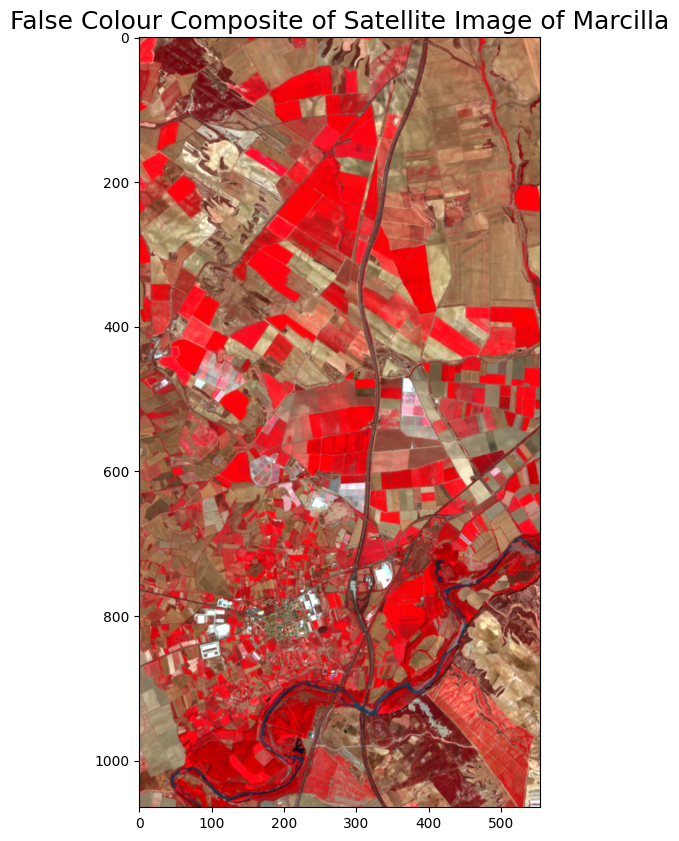

In [5]:
# Red >>>> NIR (8)
band_red = src.read(8)
# Green >>>> Red (4)
band_green = src.read(4)
# Blue >>>>> green (3)
band_blue = src.read(3)

# Apply color stretch 
def color_stretch(band, min_val, max_val):
    # Consider the maximum and minimum possible values to avoid outliers
    band = np.clip(band, min_val, max_val)
    # Scale from 0 to 255 (for display)
    band_stretched = ((band - min_val) / (max_val - min_val)) * 255
    #band_stretched = np.nan_to_num(band_stretched, nan=0)
    return band_stretched.astype(np.uint8)

# Defines the cut-off values. 
min_clip = 0  
max_clip = 0.5

red_stretched = color_stretch(band_red, min_clip, max_clip)
green_stretched = color_stretch(band_green, min_clip, max_clip)
blue_stretched = color_stretch(band_blue, min_clip, max_clip)

# Stack the bands for display
# The final stacking order should be (Red, Green, Blue)
falsergb_composite = np.dstack((red_stretched, green_stretched, blue_stretched))

# Show
plt.figure(figsize=(10, 10))
plt.imshow(falsergb_composite)
plt.title("False Colour Composite of Satellite Image of Marcilla", fontsize=18)
plt.show()

In [6]:
# Read the necessary bands
savi = src.read(27)

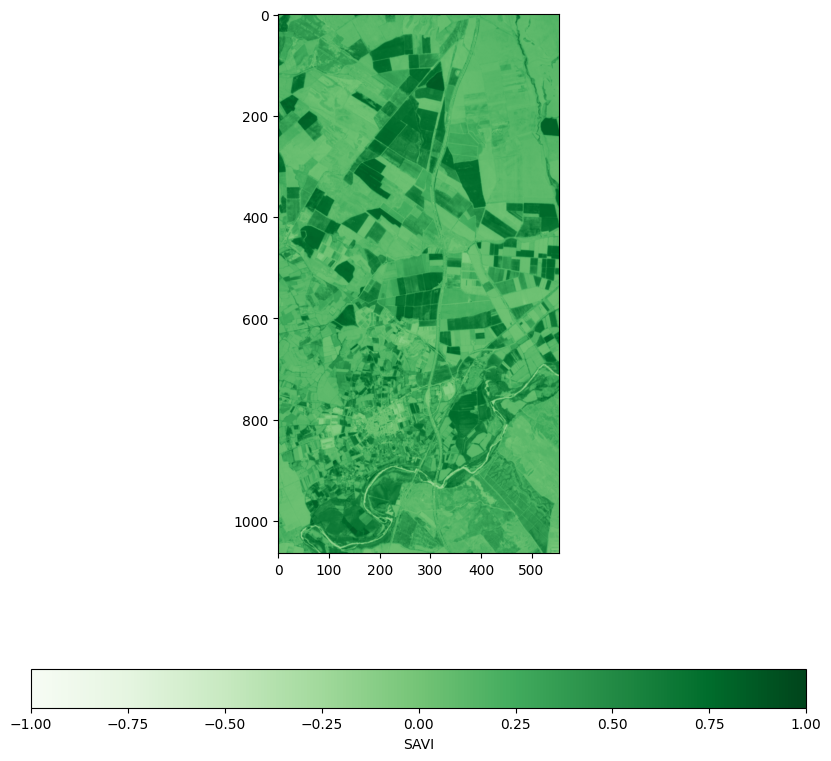

In [7]:
# Show SAVI
fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(savi, cmap='Greens', vmin=-1, vmax=1)

fig.colorbar(im, ax=ax,orientation='horizontal', label='SAVI')

plt.show()

# Time Series

In [8]:
# Read the csv file that we download from GEE
ts=pd.read_csv('SAVI_TimeSeries.csv')

In [9]:
# Split the contents of the 'date' column to get the year and month
date = (list(([x[0:7] for x in ts['date']]))) 
# Save the information in a new column
ts['Date'] = date
# Repeat the process to get only the year and month.
year = (list(([x[0:4] for x in ts['Date']])))
ts['Year'] = year
month = (list(([x[5:] for x in ts['Date']])))
ts['Month'] = month
ts

,system:index,Blue,CLASIF_SC1,COEF_AUTO,COEF_REGAD,COMARCA,ClasEsp,ClasGen,GEOM_AREA,Green,...,SAVI,SOILTAXON1,SWIR1,SWIR2,date,field_1,.geo,Date,Year,Month
0,20170320T105731_20170320T110651_T30TWM_0000000...,0.089959,"Limosa fina, Mixta, Profunda",96,0,Ribera Alta,PASTOS HERBÁCEOS,PASTOS,1.225675e+09,0.133264,...,0.206565,Fluventic Haploxerept,0.375248,0.287836,2017-03-20,32234,"{""type"":""Polygon"",""coordinates"":[[[-1.71611337...",2017-03,2017,03
1,20170320T105731_20170320T110651_T30TWM_0000000...,0.055958,"Franca gruesa, Carbonática, Profunda",85,0,Ribera Alta,PASTOS HERBÁCEOS,PASTOS,1.225675e+09,0.100870,...,0.380352,Typic Xerofluvent,0.271659,0.182098,2017-03-20,32327,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.71...",2017-03,2017,03
2,20170320T105731_20170320T110651_T30TWM_0000000...,0.064827,"Franca gruesa, Carbonática, Profunda",100,0,Ribera Alta,PASTOS HERBÁCEOS,PASTOS,1.225675e+09,0.110534,...,0.355761,Typic Xerofluvent,0.318452,0.227229,2017-03-20,32336,"{""type"":""Polygon"",""coordinates"":[[[-1.71064096...",2017-03,2017,03
3,20170320T105731_20170320T110651_T30TWM_0000000...,0.053488,"Limosa fina, Mixta, Profunda",43,0,Ribera Alta,PASTOS HERBÁCEOS,PASTOS,1.225675e+09,0.092450,...,0.388888,Fluventic Haploxerept,0.222700,0.142600,2017-03-20,32346,"{""type"":""Polygon"",""coordinates"":[[[-1.72428561...",2017-03,2017,03
4,20170320T105731_20170320T110651_T30TWM_0000000...,0.062261,"Esquelética franca, Mixta, Somera",2,0,Ribera Alta,PASTOS HERBÁCEOS,PASTOS,1.225675e+09,0.100112,...,0.273393,Petrocalcidic Palexeroll,0.271676,0.195872,2017-03-20,33034,"{""type"":""Polygon"",""coordinates"":[[[-1.73028294...",2017-03,2017,03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51796,20171230T110439_20171230T110439_T30TXN_0000000...,0.035991,"Arcillosa fina, Mixta, Profunda",100,100,Ribera Alta,TOMATE,TOMATE,1.225675e+09,0.071605,...,0.434876,Fluventic Haploxerept,0.159306,0.090531,2017-12-30,33132,"{""type"":""Polygon"",""coordinates"":[[[-1.72163189...",2017-12,2017,12
51797,20171230T110439_20171230T110439_T30TXN_0000000...,0.033444,"Arcillosa fina, Mixta, Profunda",100,100,Ribera Alta,TOMATE,TOMATE,1.225675e+09,0.067137,...,0.404765,Fluventic Haploxerept,0.162059,0.095367,2017-12-30,33133,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.71...",2017-12,2017,12
51798,20171230T110439_20171230T110439_T30TXN_0000000...,0.039605,"Arcillosa fina, Carbonática, Moderadamente pro...",100,100,Ribera Alta,TOMATE,TOMATE,1.225675e+09,0.076875,...,0.328288,Xeric Torriorthent,0.190931,0.120182,2017-12-30,33134,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.71...",2017-12,2017,12
51799,20171230T110439_20171230T110439_T30TXN_0000000...,0.034629,"Arcillosa fina, Mixta, Profunda",100,100,Ribera Alta,TOMATE,TOMATE,1.225675e+09,0.067902,...,0.365110,Fluventic Haploxerept,0.177222,0.108044,2017-12-30,33135,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.71...",2017-12,2017,12


In [10]:
# Know all the crops
list(set(ts.ClasEsp))

['SUPERFICIES FORESTALES',
 'TOMATE',
 'PASTOS ARBUSTIVOS',
 'HORTÍCOLA DE INVIERNO',
 'PASTOS ARBOLADOS',
 'FRUTALES',
 'OTROS CULTIVOS PERMANENTES',
 'ALFALFA',
 'GUISANTE',
 'CEBADA',
 'AVENA',
 'MAÍZ',
 'VIÑA',
 'HORTÍCOLA DE VERANO',
 'OLIVAR',
 'GIRASOL',
 'ALMENDROS',
 'MEZCLAS CON CEREAL',
 'PASTOS HERBÁCEOS',
 'TRIGO',
 'OTROS CULTIVOS HERBÁCEOS',
 'BARBECHO']

In [11]:
# Translate the crop's name used for SAVI visualization and save it in a new column
ts.loc[ts.ClasEsp=='GIRASOL',['Species']]='Sunflower'
ts.loc[ts.ClasEsp=='TRIGO',['Species']]='Wheat'
ts.loc[ts.ClasEsp=='SUPERFICIES FORESTALES',['Species']]='Forest'
ts.loc[ts.ClasEsp=='OLIVAR',['Species']]='Olive'
ts.loc[ts.ClasEsp=='VIÑA',['Species']]='Vineyard'
ts.loc[ts.ClasEsp=='MAÍZ',['Species']]='Maize'

In [12]:
# Filter considering six different land cover
wheat=ts.loc[(ts.Species=='Wheat')]
maize=ts.loc[(ts.Species=='Maize')]
sunflower=ts.loc[(ts.Species=='Sunflower')]
vineyard=ts.loc[(ts.Species=='Vineyard')]
forest=ts.loc[(ts.Species=='Forest')]
olive=ts.loc[(ts.Species=='Olive')]

# Print the possible identification 
print("Maize's plots ", list(set(maize.PARCELA)))
print("Wheat's plots ", list(set(wheat.PARCELA)))
print("Sunflower's plots ", list(set(sunflower.PARCELA)))
print("Vineyard's plots ", list(set(vineyard.PARCELA)))
print("Forest's plots ", list(set(forest.PARCELA)))
print("Olive's plots ", list(set(olive.PARCELA)))

Maize's plots  [528.0, 530.0, 532.0, 533.0, 534.0, 546.0, 550.0, 553.0, 555.0, 562.0, 56.0, 571.0, 66.0, 67.0, 585.0, 587.0, 594.0, 84.0, 598.0, 87.0, 88.0, 91.0, 95.0, 96.0, 97.0, 98.0, 99.0, 103.0, 105.0, 106.0, 107.0, 108.0, 618.0, 112.0, 625.0, 114.0, 113.0, 629.0, 118.0, 120.0, 124.0, 130.0, 646.0, 134.0, 139.0, 654.0, 144.0, 656.0, 657.0, 146.0, 148.0, 149.0, 151.0, 153.0, 154.0, 155.0, 156.0, 157.0, 158.0, 160.0, 673.0, 674.0, 164.0, 165.0, 680.0, 169.0, 170.0, 173.0, 174.0, 175.0, 176.0, 178.0, 180.0, 182.0, 695.0, 184.0, 697.0, 698.0, 186.0, 190.0, 705.0, 706.0, 194.0, 197.0, 202.0, 205.0, 206.0, 207.0, 208.0, 209.0, 213.0, 216.0, 219.0, 220.0, 221.0, 222.0, 223.0, 226.0, 232.0, 233.0, 234.0, 249.0, 250.0, 252.0, 260.0, 263.0, 268.0, 270.0, 283.0, 284.0, 290.0, 327.0, 1363.0, 1365.0, 343.0, 345.0, 347.0, 350.0, 1377.0, 362.0, 364.0, 365.0, 416.0, 426.0, 450.0, 451.0, 456.0, 457.0, 461.0, 462.0, 464.0, 465.0, 466.0, 467.0, 472.0, 488.0, 489.0, 495.0, 502.0]
Wheat's plots  [532.

In [20]:
# Select only one plot per land cover
selection=ts.loc[((ts.Species=='Wheat')&(ts.PARCELA==532.0))|((ts.Species=='Maize')&(ts.PARCELA==528.0))|
    ((ts.Species=='Sunflower')&(ts.PARCELA==228.0))|((ts.Species=='Vineyard')&(ts.PARCELA==226.0))|
    ((ts.Species=='Forest')&(ts.PARCELA==235.0))|((ts.Species=='Olive')&(ts.PARCELA==523.0))]

In [21]:
band_index='SAVI'

In [22]:
# Group by species and month taking into account the band/index to be represented
monthly_data = (selection.groupby(['Month', 'Species'])[band_index].mean().reset_index().rename(columns={band_index: 'Mean_Value'}))
monthly_data

,Month,Species,Mean_Value
0,03,Forest,0.245802
1,03,Maize,0.225744
2,03,Olive,0.474141
3,03,Sunflower,0.452794
4,03,Vineyard,0.188285
5,03,Wheat,0.254528
6,04,Forest,0.498573
7,04,Maize,0.320567
8,04,Olive,0.425664
9,04,Sunflower,0.663118


In [23]:
# Restructure data: Create a column for each crop 
# This is key to efficiently graphing multiple lines with pandas/matplotlib.
pivot_data = monthly_data.pivot_table(index='Month',columns='Species',values='Mean_Value')
pivot_data

Species,Forest,Maize,Olive,Sunflower,Vineyard,Wheat
Month,,,,,,
03,0.245802,0.225744,0.474141,0.452794,0.188285,0.254528
04,0.498573,0.320567,0.425664,0.663118,0.262931,0.628307
05,0.695888,0.106731,0.382303,0.062498,0.193470,0.352994
06,0.633661,0.245251,0.245007,0.074509,0.246522,0.245673
07,0.586912,0.359450,0.212817,0.150177,0.216230,0.147952
08,0.608133,0.467866,0.215393,0.284443,0.195634,0.097368
09,0.607256,0.199399,0.071065,0.291779,0.192799,0.090188
10,0.358696,0.174214,0.219013,0.157917,0.177227,0.118732
12,0.224186,0.079214,0.273575,0.083115,0.110591,0.109258


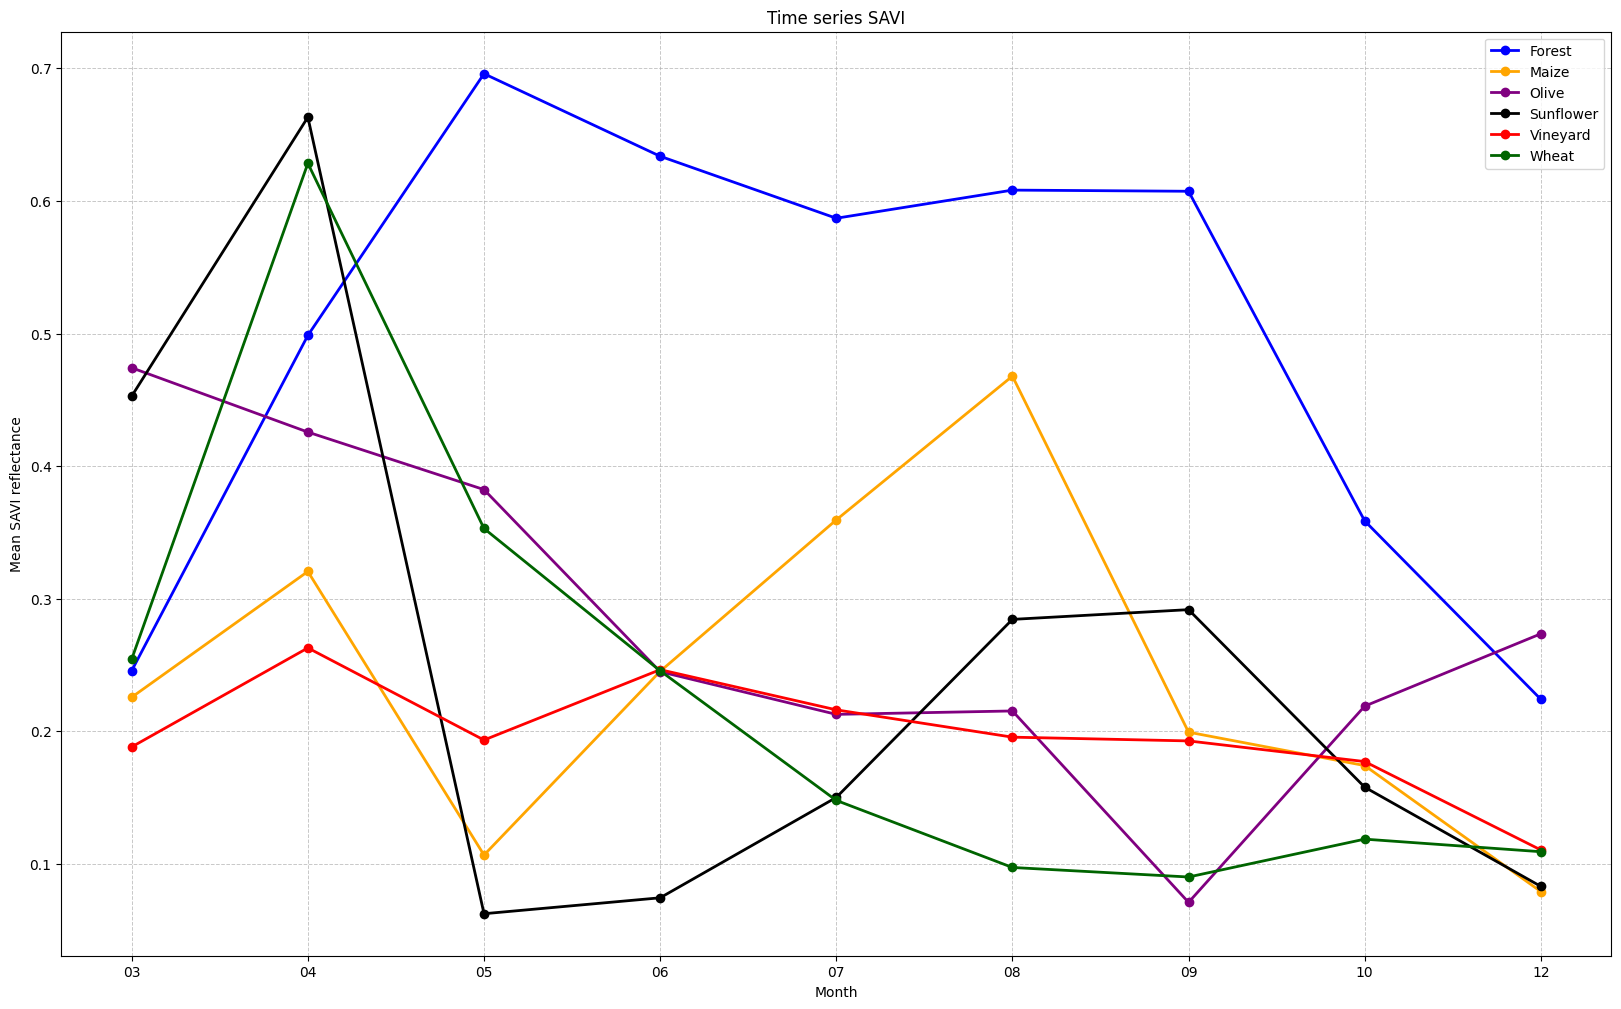

In [25]:
# Show
plt.figure(figsize=(20, 12))
# plt.plot(x, y, marker= type of marker, linestyle= type of line, color= color of line, linewidth= line thickness, label= tag for legend)

plt.plot(pivot_data.index, pivot_data['Forest'], marker='o', linestyle='-', color='blue', linewidth=2, label='Forest')
plt.plot(pivot_data.index, pivot_data['Maize'], marker='o', linestyle='-', color='orange', linewidth=2, label='Maize')
plt.plot(pivot_data.index, pivot_data['Olive'], marker='o', linestyle='-', color='purple', linewidth=2, label='Olive')
plt.plot(pivot_data.index, pivot_data['Sunflower'], marker='o', linestyle='-', color='black', linewidth=2, label='Sunflower')
plt.plot(pivot_data.index, pivot_data['Vineyard'], marker='o', linestyle='-', color='red', linewidth=2, label='Vineyard')
plt.plot(pivot_data.index, pivot_data['Wheat'], marker='o', linestyle='-', color='darkgreen', linewidth=2, label='Wheat')

plt.legend()
plt.title(f'Time series {band_index}')
plt.xlabel('Month')
plt.ylabel(f'Mean {band_index} reflectance')
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.savefig('Time_series_SAVI.png', dpi=300, bbox_inches='tight') 
# plt.show()